##Loading and Preprocessing

In [10]:
#Import Libraries
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report,confusion_matrix,accuracy_score



*   Load the breast cancer dataset from sklearn.




In [2]:
breast_cancer = load_breast_cancer()

In [4]:
X = breast_cancer.data
y = breast_cancer.target

df = pd.DataFrame(X, columns=breast_cancer.feature_names)
df["Target"] = y

print(X.shape)
df.head()


(569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0




*  Preprocess the data to handle any missing values and perform necessary feature scaling.




In [5]:
df.shape

(569, 31)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [7]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
print(X.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64










*   Loaded the Breast Cancer dataset.
*   Checked the dataset size.
*   Examined data types.
*   Generated descriptive statistics.
*   Verified that there are no missing values.










In [8]:
#Train test split
X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



*   Feature Sacling



In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Data Preprocessing Steps
1. Missing Value Handling

The dataset was checked for missing values using isnull().sum().

No missing values were found; therefore, no imputation was required.

2. Feature Scaling

The dataset contains features with different numerical ranges.

For example:

Radius
Texture
Area
Perimeter

These values vary greatly.

StandardScaler was used to standardize all features by transforming them into a distribution with:

Mean = 0
Standard Deviation = 1

Importance of Feature Scaling

Feature scaling improves the performance of algorithms such as:

Logistic Regression
Support Vector Machine (SVM)
k-Nearest Neighbors (k-NN)

These algorithms rely on distances or gradient optimization and perform better when features are on the same scale.

Decision Tree and Random Forest do not require feature scaling, but scaling the entire dataset keeps preprocessing consistent.

##Classification Algorithm Implementation

1. Logistic Regression

Logistic Regression is a supervised learning algorithm used for binary classification. It predicts probabilities using the logistic (sigmoid) function and classifies data into one of two classes.

It is suitable for this dataset because the target variable contains only two classes: malignant and benign.

In [11]:
lr_parameters = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=5000),
    lr_parameters,
    cv=5,
    scoring="accuracy"
)



In [14]:
lr_grid.fit(X_train_scaled, y_train)

lr_prediction = lr_grid.predict(X_test_scaled)

In [15]:
print("Best Parameters:", lr_grid.best_params_)
print("Accuracy:", accuracy_score(y_test, lr_prediction))

Best Parameters: {'C': 0.1, 'solver': 'lbfgs'}
Accuracy: 0.9736842105263158


2. Decision Tree Classifier

Decision Tree builds a tree-like structure by selecting the best feature at each node to split the dataset.

It is suitable because it can capture nonlinear relationships and is easy to interpret.

In [17]:
dt_parameters = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_parameters,
    cv=5,
    scoring="accuracy"
)


In [18]:
dt_grid.fit(X_train_scaled, y_train)

dt_prediction = dt_grid.predict(X_test_scaled)

In [19]:
print("Best Parameters:", dt_grid.best_params_)
print("Accuracy:", accuracy_score(y_test, dt_prediction))

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5}
Accuracy: 0.9210526315789473


3. Random Forest Classifier

Random Forest is an ensemble learning algorithm that creates multiple decision trees and combines their predictions using majority voting.

It is suitable because it reduces overfitting and generally provides high classification accuracy.

In [20]:
rf_parameters = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_parameters,
    cv=5,
    scoring="accuracy"
)



In [21]:
rf_grid.fit(X_train_scaled, y_train)

rf_prediction = rf_grid.predict(X_test_scaled)

In [22]:
print("Best Parameters:", rf_grid.best_params_)
print("Accuracy:", accuracy_score(y_test, rf_prediction))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy: 0.956140350877193


4. Support Vector Machine (SVM)

Support Vector Machine finds the optimal hyperplane that separates the classes with the maximum margin.

It is suitable because the breast cancer dataset is relatively small and has many numerical features, making SVM highly effective after feature scaling.

In [23]:
svm_parameters = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(
    SVC(),
    svm_parameters,
    cv=5,
    scoring="accuracy"
)



In [24]:
svm_grid.fit(X_train_scaled, y_train)

svm_prediction = svm_grid.predict(X_test_scaled)

In [25]:
print("Best Parameters:", svm_grid.best_params_)
print("Accuracy:", accuracy_score(y_test, svm_prediction))

Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy: 0.9824561403508771


5. k-Nearest Neighbors (k-NN)

k-NN classifies a data point based on the majority class among its nearest neighbors.

It is suitable because similar tumors tend to have similar feature values.

Feature scaling is especially important for k-NN because it uses Euclidean distance.

In [26]:
knn_parameters = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_parameters,
    cv=5,
    scoring="accuracy"
)



In [27]:
knn_grid.fit(X_train_scaled, y_train)

knn_prediction = knn_grid.predict(X_test_scaled)

In [28]:
print("Best Parameters:", knn_grid.best_params_)
print("Accuracy:", accuracy_score(y_test, knn_prediction))

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Accuracy: 0.9824561403508771


##Model Comparison

In [29]:
comparison = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Support Vector Machine",
        "K-Nearest Neighbors"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_prediction),
        accuracy_score(y_test, dt_prediction),
        accuracy_score(y_test, rf_prediction),
        accuracy_score(y_test, svm_prediction),
        accuracy_score(y_test, knn_prediction)
    ]
})

comparison.sort_values(by="Accuracy", ascending=False)

,Algorithm,Accuracy
4,K-Nearest Neighbors,0.982456
3,Support Vector Machine,0.982456
0,Logistic Regression,0.973684
2,Random Forest,0.956140
1,Decision Tree,0.921053


Accuracy comparison graph

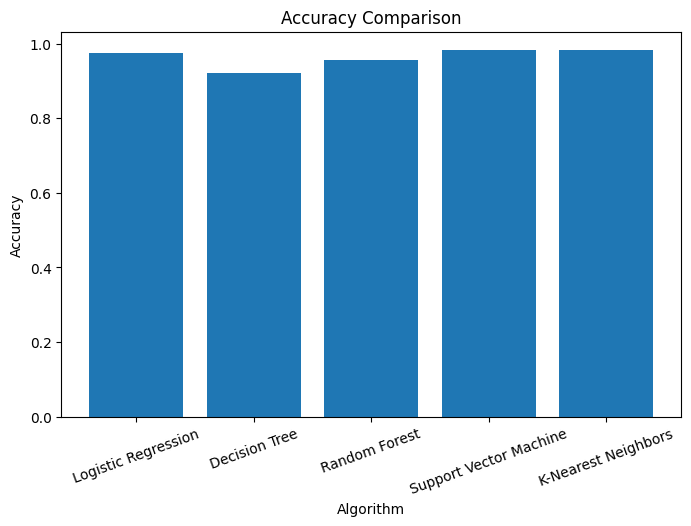

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison["Algorithm"], comparison["Accuracy"])

plt.title("Accuracy Comparison")

plt.xlabel("Algorithm")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

In [32]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]
worst_model = comparison.loc[comparison["Accuracy"].idxmin()]

print("Best Model")
print(best_model)

print()

print("Worst Model")
print(worst_model)

Best Model
Algorithm    Support Vector Machine
Accuracy                   0.982456
Name: 3, dtype: object

Worst Model
Algorithm    Decision Tree
Accuracy          0.921053
Name: 1, dtype: object
